# XỬ LÝ MISSING VALUES

## Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from scipy import stats
from scipy.stats import chi2 
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, RFECV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, IsolationForest
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import classification_report, roc_auc_score, f1_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import LocalOutlierFactor
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import MinMaxScaler, RobustScaler, QuantileTransformer, StandardScaler
from sklearn.impute import IterativeImputer
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
import category_encoders as ce
from statsmodels.stats.outliers_influence import variance_inflation_factor
import umap

c:\Users\tuann\miniconda3\envs\ml-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Dataset

In [2]:
df = pd.read_csv("weatherAUS.csv")

print(f"Data shape: {df.shape}")
print(df.info())

Data shape: (142193, 24)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142193 entries, 0 to 142192
Data columns (total 24 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           142193 non-null  object 
 1   Location       142193 non-null  object 
 2   MinTemp        141556 non-null  float64
 3   MaxTemp        141871 non-null  float64
 4   Rainfall       140787 non-null  float64
 5   Evaporation    81350 non-null   float64
 6   Sunshine       74377 non-null   float64
 7   WindGustDir    132863 non-null  object 
 8   WindGustSpeed  132923 non-null  float64
 9   WindDir9am     132180 non-null  object 
 10  WindDir3pm     138415 non-null  object 
 11  WindSpeed9am   140845 non-null  float64
 12  WindSpeed3pm   139563 non-null  float64
 13  Humidity9am    140419 non-null  float64
 14  Humidity3pm    138583 non-null  float64
 15  Pressure9am    128179 non-null  float64
 16  Pressure3pm    128212 non-null  float64
 17  Clou

Tập dữ liệu 142193 dòng và 24 cột, trong đó 2 cột RISK_MM và RainTomorrow là cột nhãn.

## Phân tích missing values và thực hiện điền khuyết

### Phân tích giá trị thiếu

CƠ SỞ LÝ THUYẾT

Trong thống kê, dữ liệu bị thiếu được chia thành 3 cơ chế chính:

1.  **MCAR (Missing Completely At Random - Thiếu hoàn toàn ngẫu nhiên):**

	*   *Định nghĩa:* Việc một giá trị bị thiếu không phụ thuộc vào bất kỳ giá trị nào khác trong tập dữ liệu (cả biến quan sát được lẫn biến bị thiếu). Khả năng bị thiếu của mọi dòng là như nhau.
	*   *Ví dụ:* Một tờ giấy ghi chép bị rách mất một góc do vô tình, làm mất một vài con số.
2.  **MAR (Missing At Random - Thiếu ngẫu nhiên):**

	*   *Định nghĩa:* Việc dữ liệu bị thiếu có thể giải thích được dựa trên **các biến khác đã được quan sát** trong tập dữ liệu, chứ không phụ thuộc vào bản thân giá trị bị thiếu.
	*   *Ví dụ:* Nam giới thường lười điền vào cột "Mức độ trầm cảm" hơn nữ giới. Việc thiếu dữ liệu ở cột "Trầm cảm" phụ thuộc vào cột "Giới tính" (đã biết).
3.  **MNAR (Missing Not At Random - Thiếu không ngẫu nhiên):**

	*   *Định nghĩa:* Việc dữ liệu bị thiếu phụ thuộc vào **chính bản thân giá trị bị thiếu đó** (hoặc các biến chưa được quan sát).
	*   *Ví dụ:* Những người có thu nhập rất cao hoặc rất thấp thường từ chối điền vào cột "Thu nhập".

**Kiểm định Little (Little's MCAR Test)**

*   **Mục đích:** Đánh giá xem *toàn bộ tập dữ liệu* có tuân theo cơ chế MCAR hay không.
*   **Giả thuyết H0 (Null Hypothesis):** Dữ liệu bị thiếu hoàn toàn ngẫu nhiên (MCAR).
*   **Giả thuyết H1 (Alternative Hypothesis):** Dữ liệu KHÔNG tuân theo MCAR (tức là MAR hoặc MNAR).
*   *Quy tắc:* Nếu **p-value < 0.05**, ta bác bỏ H0 và kết luận dữ liệu không phải là MCAR.

--- VISUALIZE MISSING DATA MATRIX ---


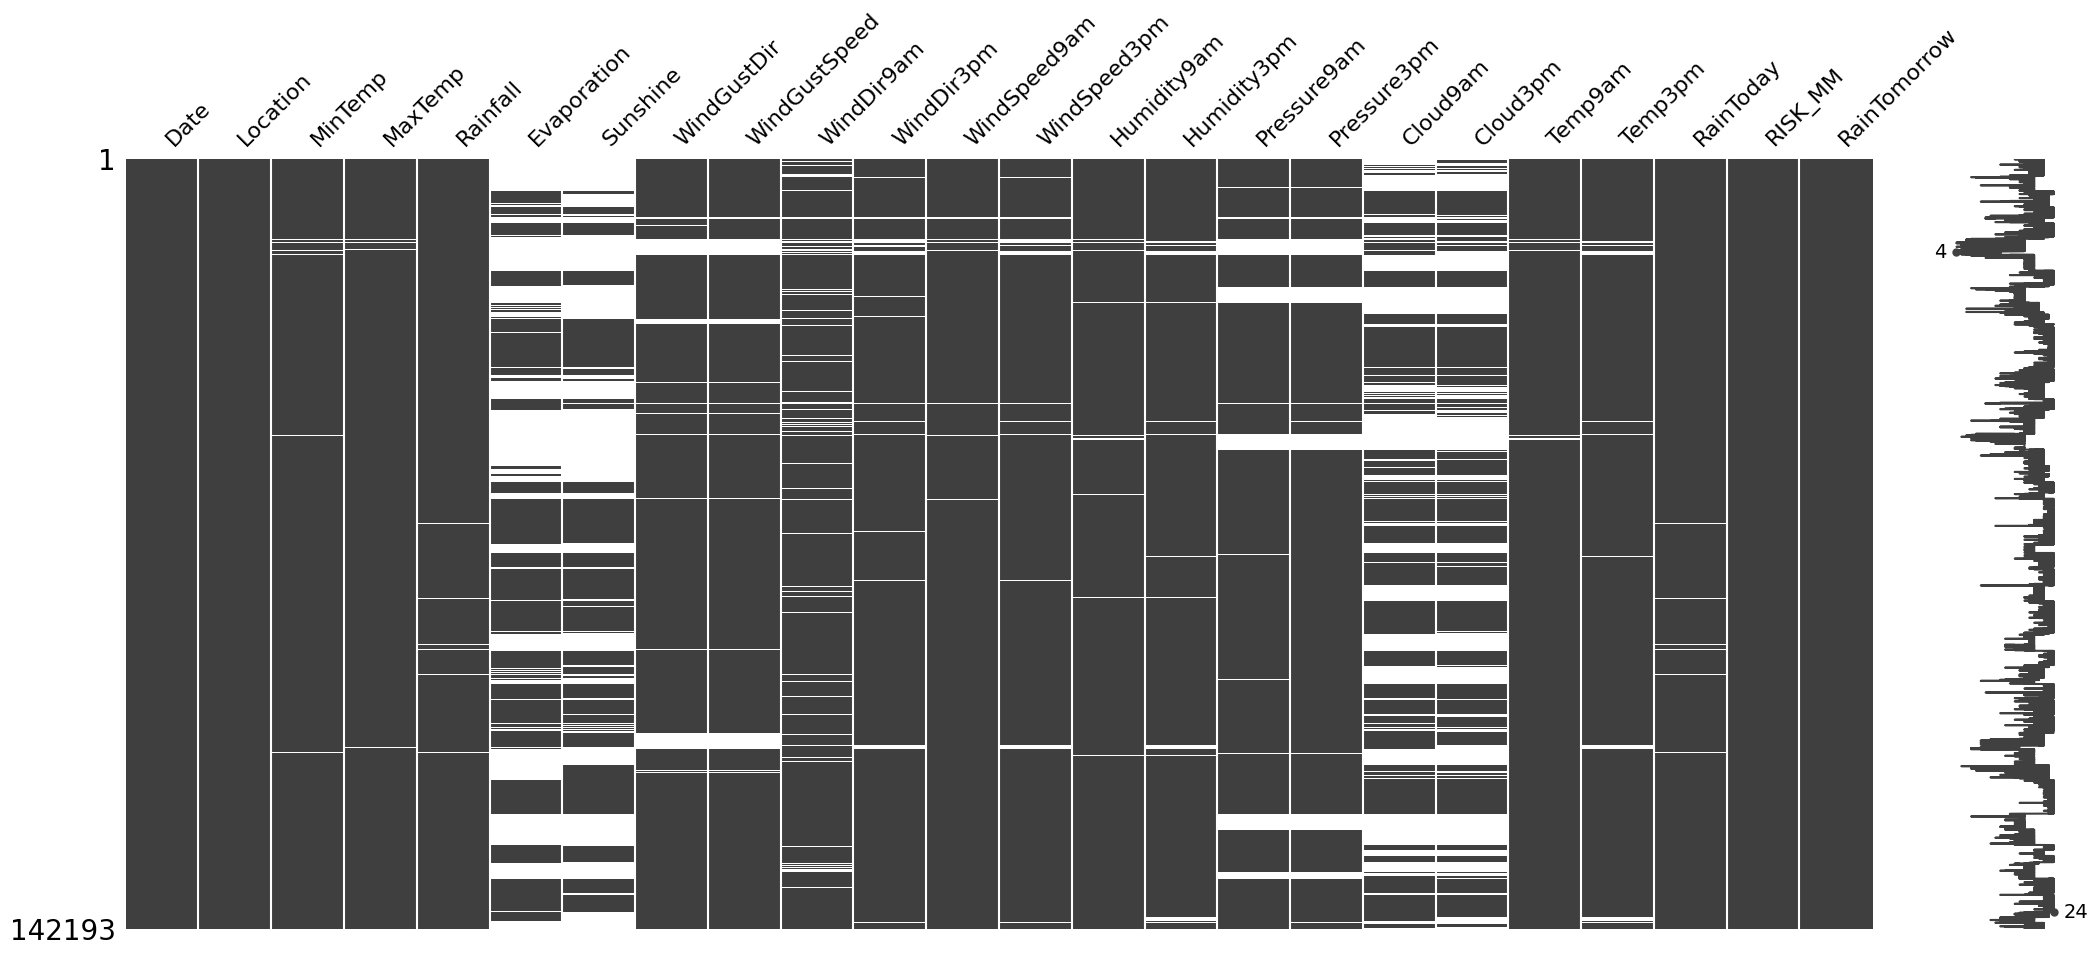

In [3]:
# 1. Visualize missing data matrix
print("--- VISUALIZE MISSING DATA MATRIX ---")
msno.matrix(df)
plt.show()

In [4]:
# 2. Specific missing rate
missing_percent = df.isnull().mean() * 100
print("Specific missing rates per column (%):")
print(missing_percent[missing_percent > 0].sort_values(ascending=False))

Specific missing rates per column (%):
Sunshine         47.692924
Evaporation      42.789026
Cloud3pm         40.152469
Cloud9am         37.735332
Pressure9am       9.855619
Pressure3pm       9.832411
WindDir9am        7.041838
WindGustDir       6.561504
WindGustSpeed     6.519308
WindDir3pm        2.656952
Humidity3pm       2.538803
Temp3pm           1.917113
WindSpeed3pm      1.849599
Humidity9am       1.247600
Rainfall          0.988797
RainToday         0.988797
WindSpeed9am      0.948007
Temp9am           0.635756
MinTemp           0.447983
MaxTemp           0.226453
dtype: float64


*   **Nhóm thiếu cực kỳ nghiêm trọng (>35%):** `Sunshine` (47.7%), `Evaporation` (42.8%), `Cloud3pm` (40.1%), `Cloud9am` (37.7%).
*   **Nhóm thiếu trung bình (5% - 10%):** `Pressure`, `WindDir`, `WindGustSpeed`.
*   **Nhóm thiếu ít (<3%):** `Temp`, `Humidity`, `Rainfall`, v.v.

#### Little’s MCAR test

In [5]:
# 3. MCAR (Little's Test)

def check_missing_dependence(data, target_col):
	results = {}
	missing_indicator = data[target_col].isnull().astype(int)
	
	for col in data.columns:
		if col == target_col:
			continue
		
		group0 = data.loc[missing_indicator == 0, col].dropna()
		group1 = data.loc[missing_indicator == 1, col].dropna()
		
		if len(group0) > 0 and len(group1) > 0:
			stat, p_val = stats.ttest_ind(group0, group1, equal_var=False)
			results[col] = p_val
	
	return results

def missing_pvalue_matrix(df):
	cols = df.columns
	matrix = pd.DataFrame(index=cols, columns=cols, dtype=float)
	
	for target in cols:
		missing_indicator = df[target].isnull().astype(int)
		
		for col in cols:
			if col == target:
				matrix.loc[target, col] = np.nan
				continue
			
			group0 = df.loc[missing_indicator == 0, col].dropna()
			group1 = df.loc[missing_indicator == 1, col].dropna()
			
			if len(group0) > 1 and len(group1) > 1:
				stat, p_val = stats.ttest_ind(group0, group1, equal_var=False)
				matrix.loc[target, col] = p_val
			else:
				matrix.loc[target, col] = np.nan
	
	return matrix

def little_mcar_test(df):
	X = df.values
	n, p = X.shape
	
	mask = ~np.isnan(X)
	mu = np.nanmean(X, axis=0)
	
	# Pairwise covariance (better)
	S = np.zeros((p, p))
	for i in range(p):
		for j in range(p):
			valid = ~np.isnan(X[:, i]) & ~np.isnan(X[:, j])
			if np.sum(valid) > 1:
				S[i, j] = np.cov(X[valid, i], X[valid, j])[0, 1]
	
	patterns = {}
	for i in range(n):
		key = tuple(mask[i])
		patterns.setdefault(key, []).append(i)
	
	chi2_stat = 0
	dof = 0
	
	for pattern, indices in patterns.items():
		indices = np.array(indices)
		obs_vars = np.where(pattern)[0]
		
		if len(obs_vars) == 0 or len(indices) < 5:
			continue
		
		X_j = X[indices][:, obs_vars]
		mu_j = np.nanmean(X_j, axis=0)
		mu_sub = mu[obs_vars]
		
		S_sub = S[np.ix_(obs_vars, obs_vars)]
		
		try:
			S_inv = np.linalg.inv(S_sub)
		except:
			S_inv = np.linalg.pinv(S_sub)
		
		diff = mu_j - mu_sub
		n_j = len(indices)
		
		chi2_stat += n_j * diff.T @ S_inv @ diff
		dof += len(obs_vars)
	
	dof -= p
	p_value = 1 - chi2.cdf(chi2_stat, dof)
	
	return chi2_stat, dof, p_value

Lấy các cột dạng số

In [6]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
df_numeric = df[numeric_cols]

Little’s MCAR test.

In [7]:
df_little_mcar = df_numeric.loc[:, df_numeric.isnull().mean() < 0.5]

df_norm_little_mcar = (df_little_mcar - df_little_mcar.mean()) / df_little_mcar.std()

chi2_stat, dof, p_val = little_mcar_test(df_norm_little_mcar)

print(f"Chi-square: {chi2_stat:.4f}")
print(f"DoF: {dof}")
print(f"p-value: {p_val:.10f}")

Chi-square: 52701.8232
DoF: 2179
p-value: 0.0000000000


*   **Chi-square:** 52701.82
*   **DoF:** 2179
*   **p-value:** `0.0000000000` (nhỏ hơn $\alpha = 0.05$ rất nhiều).
*   **Kết luận:** Bác bỏ hoàn toàn giả thuyết H0. Cơ chế thiếu dữ liệu của bộ dữ liệu này **KHÔNG PHẢI là MCAR**. Sự vắng mặt của dữ liệu có tính hệ thống và phụ thuộc vào các yếu tố khác.

Phụ thuộc thiếu của từng cột.

In [8]:
for target in numeric_cols:
	print(f"\n--- Missing Data Mechanism for {target} ---")
	p_values = check_missing_dependence(df_numeric, target)
	for col, p_val in p_values.items():
		mechanism = "MAR/MNAR" if p_val < 0.05 else "Possibly MCAR"
		print(f"  With {col}: p-value = {p_val:.10f} -> {mechanism}")


--- Missing Data Mechanism for MinTemp ---
  With MaxTemp: p-value = 0.7519670145 -> Possibly MCAR
  With Rainfall: p-value = 0.1291934405 -> Possibly MCAR
  With Evaporation: p-value = 0.0725971293 -> Possibly MCAR
  With Sunshine: p-value = 0.2428443814 -> Possibly MCAR
  With WindGustSpeed: p-value = 0.1329846324 -> Possibly MCAR
  With WindSpeed9am: p-value = 0.0000002113 -> MAR/MNAR
  With WindSpeed3pm: p-value = 0.0000000008 -> MAR/MNAR
  With Humidity9am: p-value = 0.0005801664 -> MAR/MNAR
  With Humidity3pm: p-value = 0.0002481151 -> MAR/MNAR
  With Pressure9am: p-value = 0.2572148452 -> Possibly MCAR
  With Pressure3pm: p-value = 0.1453971338 -> Possibly MCAR
  With Cloud9am: p-value = 0.2982407038 -> Possibly MCAR
  With Cloud3pm: p-value = 0.8497518987 -> Possibly MCAR
  With Temp9am: p-value = 0.3985340918 -> Possibly MCAR
  With Temp3pm: p-value = 0.9880443275 -> Possibly MCAR
  With RISK_MM: p-value = 0.0074886097 -> MAR/MNAR

--- Missing Data Mechanism for MaxTemp ---
 

Ma trận phụ thuộc thiếu của từng cột.

In [9]:
pval_matrix = missing_pvalue_matrix(df_numeric)
print(pval_matrix.head())

              MinTemp        MaxTemp      Rainfall    Evaporation  \
MinTemp           NaN   7.519670e-01  1.291934e-01   7.259713e-02   
MaxTemp      0.025487            NaN  4.761314e-01   1.762374e-01   
Rainfall     0.319122   2.021048e-05           NaN   5.793824e-04   
Evaporation  0.000000   0.000000e+00  1.749631e-49            NaN   
Sunshine     0.000000  1.152949e-167  2.824777e-01  9.198615e-105   

                 Sunshine  WindGustSpeed   WindSpeed9am   WindSpeed3pm  \
MinTemp      2.428444e-01   1.329846e-01   2.112787e-07   8.290804e-10   
MaxTemp      6.477846e-01   1.357295e-01   2.606650e-06   1.516569e-05   
Rainfall     7.466900e-09   4.081759e-04   6.175827e-07   8.045519e-03   
Evaporation  9.408302e-20   4.179602e-22  4.759358e-260  1.185856e-157   
Sunshine              NaN   1.034122e-95   0.000000e+00   0.000000e+00   

             Humidity9am    Humidity3pm   Pressure9am   Pressure3pm  \
MinTemp         0.000580   2.481151e-04  2.572148e-01  1.453971e-01  

Biểu đồ heatmap phụ thuộc thiếu của từng cột.

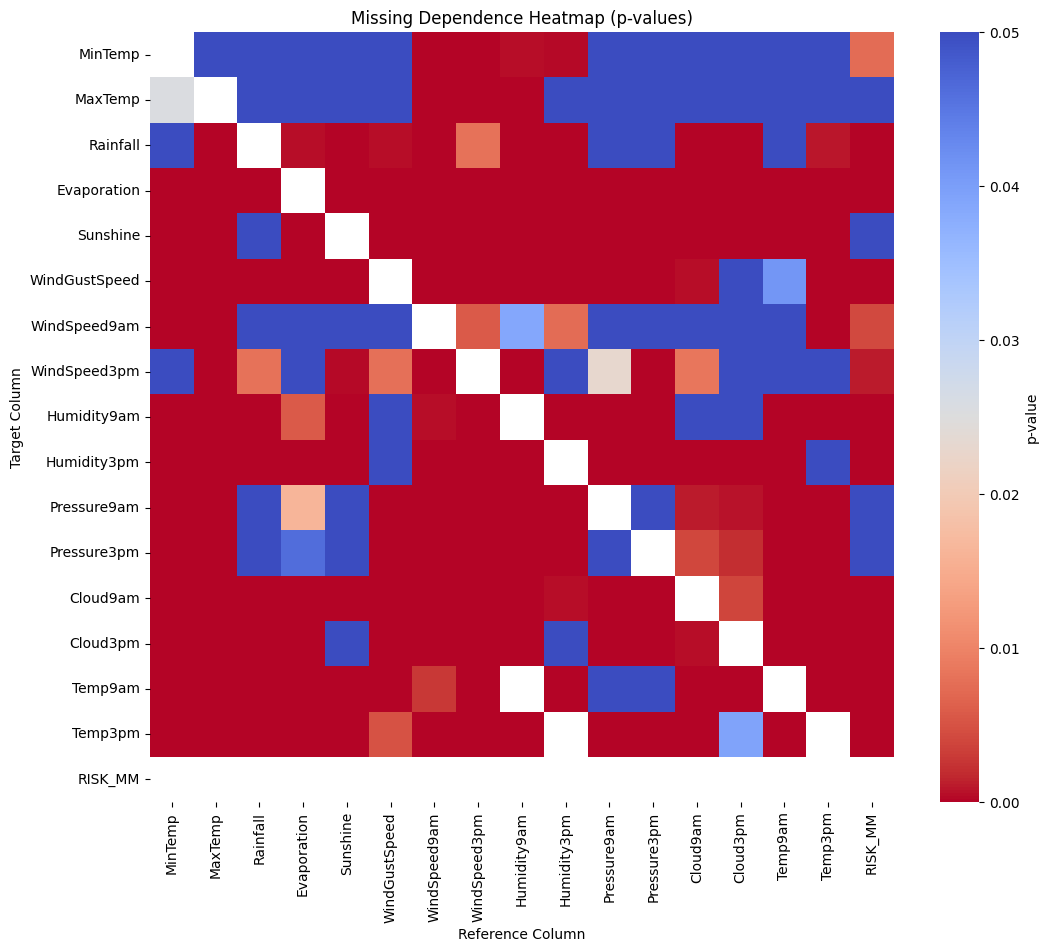

In [10]:
plt.figure(figsize=(12, 10))

sns.heatmap(
	pval_matrix,
	annot=False,
	cmap="coolwarm_r",
	vmin=0,
	vmax=0.05,
	cbar_kws={"label": "p-value"}
)

plt.title("Missing Dependence Heatmap (p-values)")
plt.xlabel("Reference Column")
plt.ylabel("Target Column")
plt.show()

Đa số là ô đỏ, điều này cho thấy tập dữ liệu có missing của một biến phụ thuộc vào nhiều biến khác.

### Xử lý giá trị thiếu bằng các phương pháp khác nhau

CƠ SỞ LÝ THUYẾT

**1. Tại sao phải đánh giá bằng RMSE trên tập MCAR nhân tạo?**

Để biết một phương pháp điền khuyết có tốt hay không, ta lấy một tập dữ liệu *đang có đầy đủ giá trị*, cố tình xóa đi 10% dữ liệu một cách hoàn toàn ngẫu nhiên (MCAR). Sau đó, ta dùng các thuật toán để dự đoán và điền lại các ô bị xóa này. Cuối cùng, so sánh "giá trị dự đoán" với "giá trị thực tế (đã bị giấu đi)" bằng độ đo **RMSE (Root Mean Squared Error)**.
*   **RMSE càng nhỏ:** Thuật toán dự đoán càng gần với giá trị gốc $\rightarrow$ Chiến lược càng tốt.

**2. Các chiến lược điền khuyết**

*   **Nhóm Simple Imputation (Mean, Median, Mode - Most Frequent):**
	*   *Cách hoạt động:* Tính trung bình, trung vị hoặc giá trị xuất hiện nhiều nhất của cột đó và điền cho toàn bộ ô thiếu.
	*   *Ưu/Nhược:* Cực kỳ nhanh. Nhưng nó bỏ qua hoàn toàn mối quan hệ giữa các biến số và làm bóp méo phương sai của dữ liệu.
*	**Regression Imputation:**
  	* 	*Cách hoạt động:* Xây dựng một mô hình hồi quy để dự đoán giá trị bị thiếu dựa trên các biến còn lại. Biến cần điền sẽ được xem như biến mục tiêu (*target*), còn các cột khác đóng vai trò biến đầu vào (*features*). Sau khi huấn luyện trên các dòng đầy đủ dữ liệu, mô hình sẽ dự đoán giá trị cho các ô bị thiếu.
  	* 	*Ưu điểm:* Khai thác được mối quan hệ giữa các biến nên thường chính xác hơn Simple Imputation. Giữ được xu hướng và cấu trúc dữ liệu tốt hơn.
  	* 	*Nhược điểm:* Dễ gây *overfitting* hoặc tạo ra dữ liệu “quá hoàn hảo” vì giá trị điền vào nằm đúng trên mô hình hồi quy, làm giảm độ biến thiên tự nhiên của dữ liệu. Hiệu quả giảm mạnh nếu mối quan hệ giữa các biến phi tuyến hoặc dữ liệu chứa nhiều nhiễu.

*   **Nhóm K-Nearest Neighbors (KNN Imputation):**
	*   *Cách hoạt động:* Khi một dòng bị thiếu giá trị, thuật toán sẽ tìm kiếm $K$ dòng (neighbors) có đặc điểm giống với dòng này nhất (dựa trên các biến khác) và lấy trung bình giá trị của $K$ dòng đó để điền vào.
	*   *Ví dụ:* Một ngày bị thiếu Nhiệt độ, thuật toán sẽ tìm $K$ ngày có Độ ẩm, Áp suất, Tốc độ gió... tương đương nhất để lấy nhiệt độ trung bình điền vào.
*   **MICE (Multiple Imputation by Chained Equations - Iterative Imputer):**
	*   *Cách hoạt động:* Xây dựng mô hình học máy (thường là hồi quy tuyến tính - Bayesian Ridge) để dự đoán giá trị thiếu. Quá trình này lặp đi lặp lại qua các biến (round-robin) cho đến khi các giá trị hội tụ. MICE khai thác triệt để sự tương quan đa biến.

In [11]:
target_cols = [
	'MinTemp', 'MaxTemp', 'Rainfall',
]

In [12]:
SAMPLE_SIZE = 20000
KNN_K_VALUES = [3, 5, 10]

df_sample = df_numeric.sample(SAMPLE_SIZE, random_state=42).reset_index(drop=True)

results = []

def calculate_rmse(imputed_df):
	return np.sqrt(mean_squared_error(
		original_values[missing_mask],
		imputed_df.loc[missing_mask, target_col]
	))

for target_col in target_cols:
	df_clean = df_sample.dropna(subset=[target_col]).copy()
	original_values = df_clean[target_col].copy()

	np.random.seed(42)
	missing_mask = np.random.rand(len(df_clean)) < 0.10

	df_missing = df_clean.copy()
	df_missing.loc[missing_mask, target_col] = np.nan

	# SCALING KNN/MICE
	scaler = StandardScaler()
	df_scaled = pd.DataFrame(
		scaler.fit_transform(df_missing),
		columns=df_missing.columns
	)

	# 1. SIMPLE IMPUTER
	for strategy in ['mean', 'median', 'most_frequent']:
		imputer = SimpleImputer(strategy=strategy)
		imputed = imputer.fit_transform(df_missing)
		df_imputed = pd.DataFrame(imputed, columns=df_missing.columns)
		
		results.append({
			'Target': target_col,
			'Strategy': strategy,
			'RMSE': calculate_rmse(df_imputed)
		})

	# 2. Regression Imputation
	regression_imputer = SimpleImputer(strategy='median')
	df_regression = pd.DataFrame(
		regression_imputer.fit_transform(df_missing),
		columns=df_missing.columns,
		index=df_missing.index
	)

	regression_model = LinearRegression()
	predictor_cols = [col for col in df_missing.columns if col != target_col]
	observed_mask = df_missing[target_col].notna()
	missing_target_mask = df_missing[target_col].isna()

	regression_model.fit(
		df_regression.loc[observed_mask, predictor_cols],
		df_regression.loc[observed_mask, target_col]
	)

	df_regression.loc[missing_target_mask, target_col] = regression_model.predict(
		df_regression.loc[missing_target_mask, predictor_cols]
	)

	results.append({
		'Target': target_col,
		'Strategy': 'Regression',
		'RMSE': calculate_rmse(df_regression)
	})

	# 2. KNN
	for k in KNN_K_VALUES:
		knn = KNNImputer(n_neighbors=k)
		imputed_scaled = knn.fit_transform(df_scaled)

		# inverse scale
		df_imputed = pd.DataFrame(
			scaler.inverse_transform(imputed_scaled),
			columns=df_missing.columns
		)

		results.append({
			'Target': target_col,
			'Strategy': f'KNN(k={k})',
			'RMSE': calculate_rmse(df_imputed)
		})

	# 3. MICE
	mice = IterativeImputer(random_state=42)

	imputed_scaled = mice.fit_transform(df_scaled)

	df_imputed = pd.DataFrame(
		scaler.inverse_transform(imputed_scaled),
		columns=df_missing.columns
	)

	results.append({
		'Target': target_col,
		'Strategy': 'MICE',
		'RMSE': calculate_rmse(df_imputed)
	})

c:\Users\tuann\miniconda3\envs\ml-env\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
c:\Users\tuann\miniconda3\envs\ml-env\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
c:\Users\tuann\miniconda3\envs\ml-env\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [13]:
results_df = pd.DataFrame(results)

pivot_table = results_df.pivot(
	index='Target',
	columns='Strategy',
	values='RMSE'
)

print(pivot_table)

Strategy  KNN(k=10)  KNN(k=3)  KNN(k=5)      MICE  Regression      mean  \
Target                                                                    
MaxTemp    5.432577  7.085355  6.633928  1.315894    1.646595  7.181771   
MinTemp    2.987936  4.910162  3.758876  2.101830    2.132555  6.502207   
Rainfall   7.752452  8.043761  7.856560  7.994884    8.037212  8.760343   

Strategy    median  most_frequent  
Target                             
MaxTemp   7.218508       7.878918  
MinTemp   6.506054       7.258461  
Rainfall  9.029623       9.029623  



PHÂN TÍCH KẾT QUẢ BẢNG RMSE

1.  **Nhóm Simple (Mean/Median/Mode) luôn xếp bét bảng:**
	*   Điểm RMSE của nhóm này luôn cao nhất ở cả 3 mục tiêu. Điều này minh chứng rõ ràng cho việc: Dữ liệu thời tiết có tính liên kết chặt chẽ (ví dụ: nhiệt độ liên quan đến áp suất và độ ẩm), việc điền một con số tĩnh (static) cho mọi ô thiếu là sự lười biếng và mang lại sai số rất lớn.
2.  **Sự vượt trội tuyệt đối của MICE và Regression trên nhóm Nhiệt độ (`MaxTemp`, `MinTemp`):**
	*   Với `MaxTemp`, MICE đạt RMSE chỉ **1.31**, Regression đạt **1.65** bỏ xa phương pháp KNN-10.
	*   *Nguyên nhân:* Nhớ lại bài toán **Phân tích Đa cộng tuyến** ở bước trước. Các biến nhiệt độ (MinTemp, MaxTemp, Temp9am, Temp3pm) có **tương quan tuyến tính (r > 0.9)** cực kỳ mạnh với nhau. Thuật toán MICE và Regression đều sử dụng mô hình hồi quy tuyến tính nên nó nắm bắt được quy luật này một cách hoàn hảo $\rightarrow$ Dự đoán cực kỳ chính xác.
3.  **Hành vi của KNN ($K$ lớn vs $K$ nhỏ):**
	*   K=10 luôn cho kết quả tốt hơn K=5 và K=3 trên cả 3 biến. Việc lấy trung bình từ nhiều "hàng xóm" hơn giúp kết quả ổn định, loại bỏ được các nhiễu cục bộ so với việc chỉ tin tưởng 3 người hàng xóm gần nhất.
4.  **Tại sao `Rainfall` lại có kết quả khác biệt?**
	*   Trên biến `Rainfall` (Lượng mưa), KNN-10 (7.75) lại vượt nhẹ MICE (7.99).
	*   *Nguyên nhân:* Lượng mưa là một biến không có phân phối chuẩn và **bị lệch (skewed) cực kỳ nặng** (đa số các ngày là 0mm, nhưng có ngày bão lên tới cả trăm mm). Các mô hình tuyến tính trong MICE gặp khó khăn khi dự đoán các phân phối dạng này. Ngược lại, KNN không giả định phân phối, nó chỉ đơn giản là tìm những ngày có mây mù/áp suất tương tự để map giá trị sang, nên bắt được các đỉnh của lượng mưa tốt hơn.

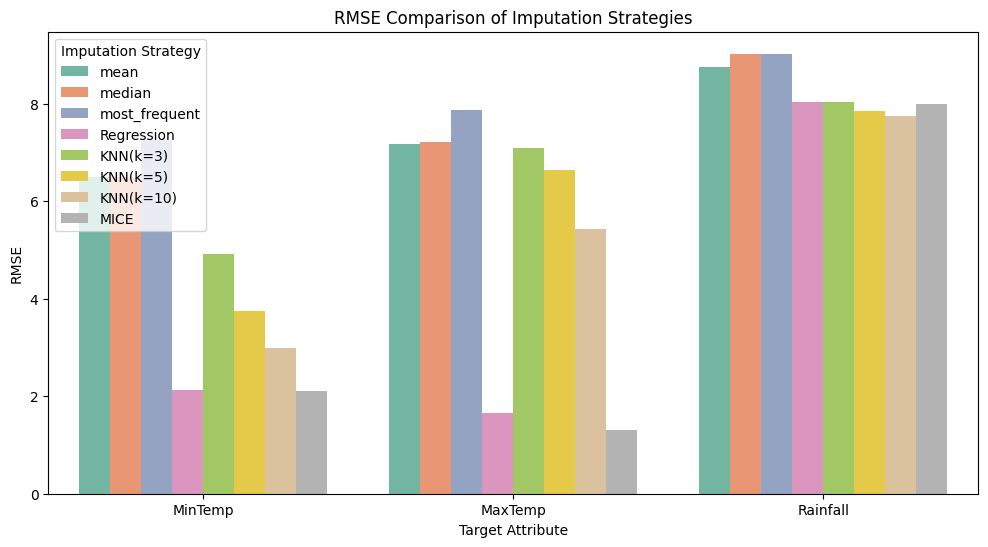

In [14]:
# bar plot comparison
plt.figure(figsize=(12, 6))

sns.barplot(
	data=results_df,
	x='Target',
	y='RMSE',
	hue='Strategy',
	palette='Set2'
)

plt.title("RMSE Comparison of Imputation Strategies")
plt.ylabel("RMSE")
plt.xlabel("Target Attribute")
plt.legend(title='Imputation Strategy')
plt.show()

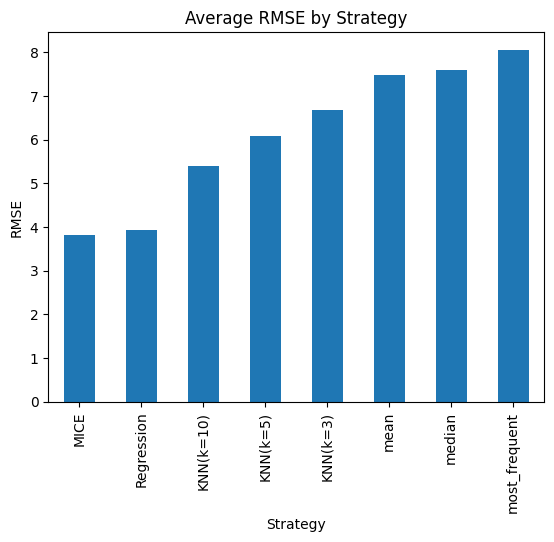

In [15]:
mean_rmse = results_df.groupby('Strategy')['RMSE'].mean().sort_values()

mean_rmse.plot(kind='bar', title='Average RMSE by Strategy')
plt.ylabel("RMSE")
plt.show()

2 biểu đồ trên cho thấy MICE đã kết quả tốt, xấp xỉ với Regression, sau đó tới KNN giảm dần theo k, cuối cùng là các chiến lược điền khuyết cơ bản.

Dựa trên các phân tích thống kê và đánh giá thực tiễn, **CHIẾN LƯỢC TỐT NHẤT ĐƯỢC CHỌN LÀ: MICE (Iterative Imputer).**

**Lý giải cho sự lựa chọn:**

1.  **Chiến thắng áp đảo trên đa số các biến:** Dù thua KNN-10 một khoảng rất nhỏ trên `Rainfall` (lệch ~0.24), nhưng MICE lại mang lại mức độ chính xác khổng lồ trên `MaxTemp` (giảm sai số gấp 4 lần) và `MinTemp`. Xét trên tổng thể toàn bộ tập dữ liệu, MICE là thuật toán ưu việt nhất.
2.  **Phù hợp với bản chất dữ liệu (MAR/MNAR):** Ở bài toán trước, Little's MCAR Test đã chứng minh dữ liệu này bị thiếu theo cơ chế có hệ thống (MAR/MNAR). MICE sinh ra chính xác là để giải quyết cơ chế MAR bằng cách khai thác thông tin từ các cột không bị thiếu (như lấy độ ẩm để dự đoán nhiệt độ).
3.  **Tối ưu phần cứng hơn KNN với dữ liệu lớn:** Bộ dữ liệu thời tiết thường có hàng trăm nghìn dòng. Mỗi khi KNN dự đoán một ô thiếu, nó phải tính khoảng cách Euclid của ô đó với *toàn bộ* các dòng còn lại trong tập dữ liệu, làm chi phí tính toán và bộ nhớ tăng theo cấp số nhân ($O(N^2)$). Trong khi đó, MICE chỉ huấn luyện một mô hình hồi quy ($O(N)$), thời gian chạy trên Production sẽ nhanh và khả thi hơn rất nhiều.